In [2]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
calidataset = fetch_california_housing()
print(calidataset)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8)), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset

In [13]:
df = pd.DataFrame(calidataset.data, columns = calidataset.feature_names)
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


**Inter Quartile range calculation for Outlier detection and plot in Box plot for AveRooms**

In [ ]:
# initialize  Quartiles 1 and 2
column = 'AveRooms'
Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)
# Calculate IQR
IQR = Q3 - Q1
# Define lower and upper bound
lower_bound = Q1 - IQR * 1.5
upper_bound = Q3 + IQR * 1.5

print(f"Column : {column}")
print(f"IQR: {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f} | Upper Bound : {upper_bound:.2f}")


Column : AveRooms
IQR: 1.61
Lower bound: 2.02 | Upper Bound : 8.47


In [17]:
#filter the dataframe for outliers
outliers = df[(df[column]< lower_bound) | (df[column]> upper_bound)]
print(f"Total Rows: {len(df)}")
print(f"Outlier Rows: {len(outliers)}")

Total Rows: 20640
Outlier Rows: 511


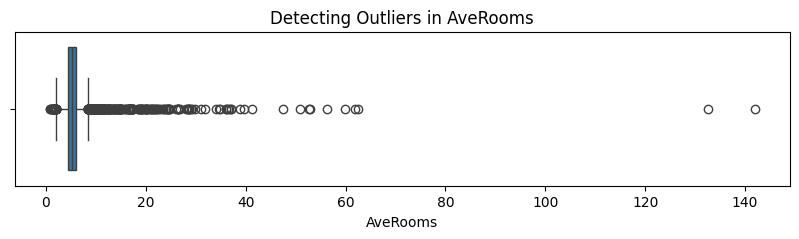

In [18]:
# Visualize with a box plot
plt.figure(figsize = (10,2)) # 10 inches wide and 2 inches tall for the canvas
sns.boxplot(x = df[column])
plt.title(f"Detecting Outliers in {column}")
plt.show()

In [ ]:
# keep only the data within the bounds
df_cleaned = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
print(f"Shape before {df.shape}")                        # shape gives row ,columns
print(f"Shape after {df_cleaned.shape}")

Shape before (20640, 8)
Shape after (20129, 8)


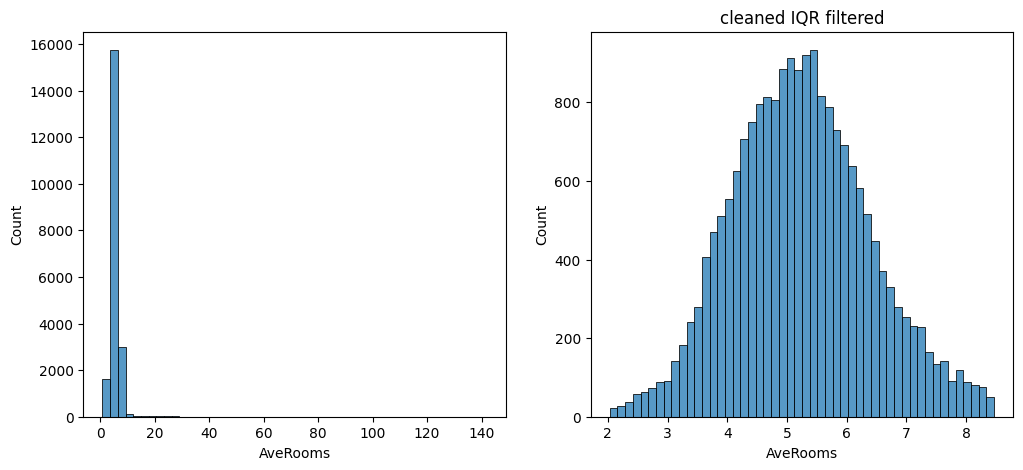

In [29]:
# compare the distribution before and after outlier cleaning
fig, ax = plt.subplots(1,2, figsize = (12,5))
sns.histplot(df[column], bins = 50, ax = ax[0])
plt.title("Original with outliers")
# bins = 50 divides the data into 50 evenly spaced bars
sns.histplot(df_cleaned[column], bins = 50, ax = ax[1])
plt.title("cleaned IQR filtered")
plt.show()


**Inter Quartile range calculation for Outlier detection and plot in Box plot for AveBedrms**

In [30]:
# initialize  Quartiles 1 and 2
column = 'AveBedrms'
Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)
# Calculate IQR
IQR = Q3 - Q1
# Define lower and upper bound
lower_bound = Q1 - IQR * 1.5
upper_bound = Q3 + IQR * 1.5

print(f"Column : {column}")
print(f"IQR: {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f} | Upper Bound : {upper_bound:.2f}")

Column : AveBedrms
IQR: 0.09
Lower bound: 0.87 | Upper Bound : 1.24


In [31]:
#filter the dataframe for outliers
outliers = df[(df[column]< lower_bound) | (df[column]> upper_bound)]
print(f"Total Rows: {len(df)}")
print(f"Outlier Rows: {len(outliers)}")

Total Rows: 20640
Outlier Rows: 1424


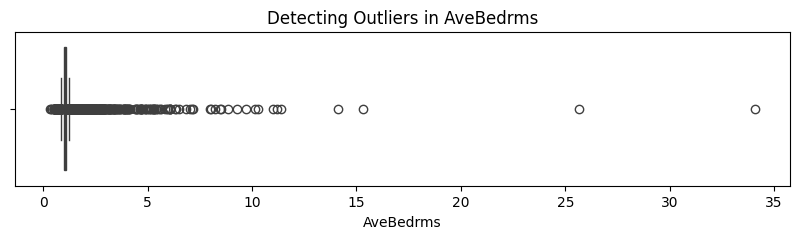

In [38]:
# Visualize with a box plot
plt.figure(figsize = (10,2)) # 10 inches wide and 2 inches tall for the canvas
sns.boxplot(x = df[column])
plt.title(f"Detecting Outliers in {column}")
plt.show()

In [33]:
# keep only the data within the bounds
df_cleaned = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
print(f"Shape before {df.shape}")                        # shape gives row ,columns
print(f"Shape after {df_cleaned.shape}")

Shape before (20640, 8)
Shape after (19216, 8)


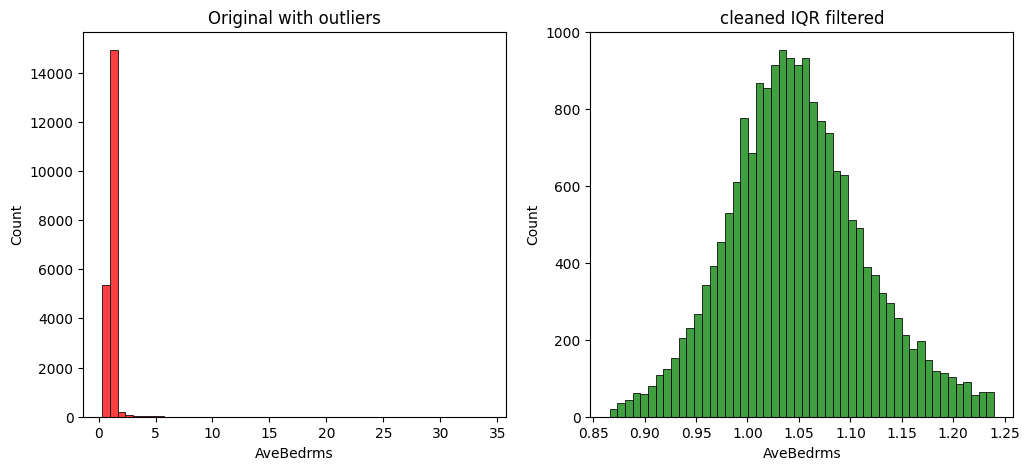

In [63]:
# compare the distribution before and after outlier cleaning
fig, ax = plt.subplots(1,2, figsize = (12,5))
sns.histplot(df[column], bins = 50, ax = ax[0], color = "Red")
ax[0].set_title("Original with outliers")
# bins = 50 divides the data into 50 evenly spaced bars
sns.histplot(df_cleaned[column], bins = 50, ax = ax[1], color = "Green")
plt.title("cleaned IQR filtered")
plt.show()

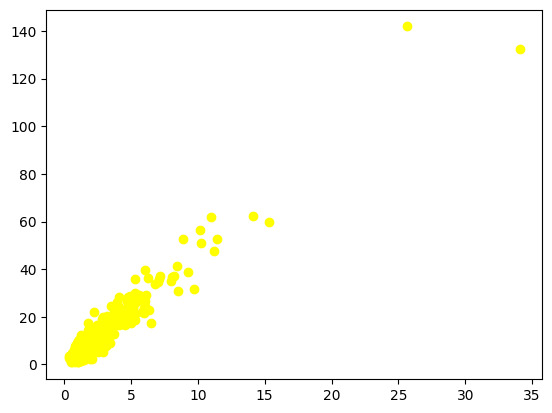

In [51]:
plt.scatter(df[column], df["AveRooms"], color = "Yellow")

<BarContainer object of 19216 artists>

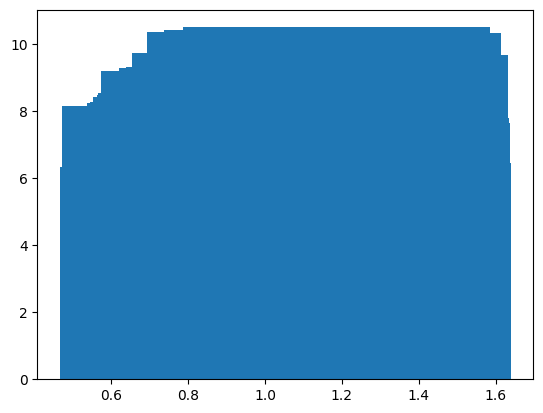

In [60]:
plt.bar(df_cleaned[column],df_cleaned["AveRooms"])